# Treino do Modelo LSTM — Disney (DIS)
Construção, treino e avaliação do modelo de redes neurais LSTM para previsão do preço de fechamento da ação DIS.

## 1. Imports e configurações

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import json

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

DATA_DIR  = '../data'
MODEL_DIR = '../model'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'TensorFlow: {tf.__version__}  |  Keras: {keras.__version__}')

TensorFlow: 2.17.0  |  Keras: 3.5.0


## 2. Carregamento dos dados pré-processados
Leitura dos arrays `.npy` e do `scaler` gerados pelo notebook de pré-processamento.

In [2]:
X_train = np.load(f'{DATA_DIR}/X_train.npy')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')
scaler  = joblib.load(f'{DATA_DIR}/scaler.pkl')

with open(f'{DATA_DIR}/preprocessing_metadata.json') as f:
    meta = json.load(f)

WINDOW_SIZE = meta['window_size']

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print(f'Janela  : {WINDOW_SIZE} dias')

X_train : (1257, 60, 1)  |  y_train : (1257,)
X_test  : (330, 60, 1)   |  y_test  : (330,)
Janela  : 60 dias


## 3. Arquitetura do modelo LSTM
Duas camadas LSTM empilhadas com Dropout para regularização, seguidas de camadas Dense para a saída.

In [3]:
def build_model(window_size: int) -> keras.Model:
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mean_squared_error'
    )
    return model

model = build_model(WINDOW_SIZE)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Callbacks de treino
- **EarlyStopping**: interrompe se a val_loss não melhorar por 15 épocas e restaura os melhores pesos
- **ModelCheckpoint**: salva o melhor modelo automaticamente
- **ReduceLROnPlateau**: reduz a taxa de aprendizado pela metade se a val_loss estabilizar por 7 épocas

In [4]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{MODEL_DIR}/lstm_dis_best.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

## 5. Treino do modelo
Treino com até 100 épocas, batch de 32 e 20% dos dados de treino como validação.

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    shuffle=False,
    verbose=1
)

print(f'\nMelhor val_loss: {min(history.history["val_loss"]):.6f}')
print(f'Épocas treinadas: {len(history.history["loss"])}')

Epoch 1/100


 1/32 ━━━━━━━━━━━━━━━━━━━━ 29s 967ms/step - loss: 0.0231

 3/32 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0237  

 5/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0232

 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0215

...


Epoch 54: val_loss did not improve from 0.00137


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0010 - val_loss: 0.0014 - learning_rate: 1.5625e-05


Epoch 54: early stopping


Restoring model weights from the end of the best epoch: 39.



Melhor val_loss: 0.001375
Épocas treinadas: 54


## 6. Curvas de aprendizado
Visualização da perda (MSE) nos conjuntos de treino e validação ao longo das épocas.

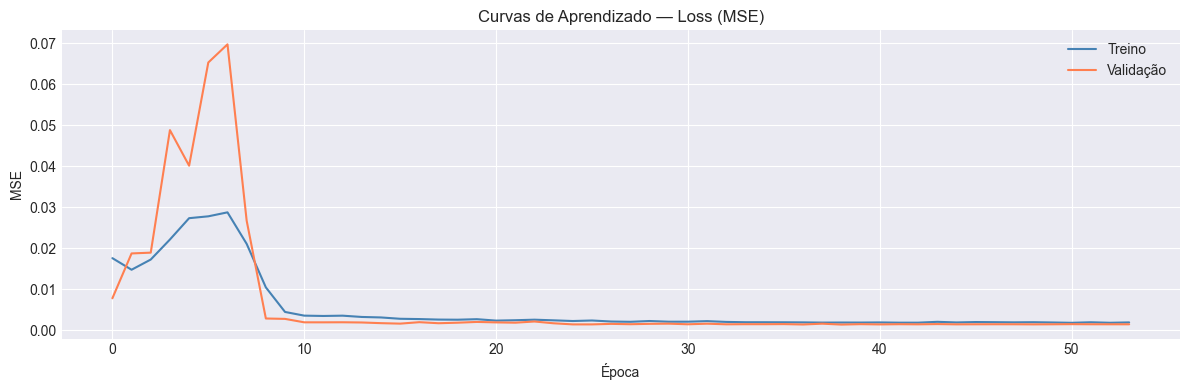

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'],     label='Treino',    color='steelblue')
plt.plot(history.history['val_loss'], label='Validação', color='coral')
plt.title('Curvas de Aprendizado — Loss (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/learning_curves.png', dpi=120)
plt.show()

## 7. Previsões no conjunto de teste
Geração das previsões e inversão da normalização para obter os valores reais em USD.

In [7]:
y_pred_scaled = model.predict(X_test, verbose=0)

# Desnormaliza para USD
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

print(f'Previsões — min: {y_pred.min():.2f}  max: {y_pred.max():.2f}')
print(f'Reais     — min: {y_real.min():.2f}  max: {y_real.max():.2f}')

Previsões — min: 94.47  max: 122.07
Reais     — min: 79.32  max: 122.82


## 8. Métricas de avaliação
Cálculo de MAE, RMSE e MAPE para medir a precisão das previsões.

In [8]:
mae  = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

metrics = {'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'MAPE': round(mape, 4)}

print('=== Métricas no Conjunto de Teste ===')
for k, v in metrics.items():
    print(f'  {k}: {v}')

=== Métricas no Conjunto de Teste ===
  MAE: 5.3155
  RMSE: 6.7861
  MAPE: 5.9732


## 9. Visualização das previsões
Comparação entre os preços reais e os previstos pelo modelo no período de teste.

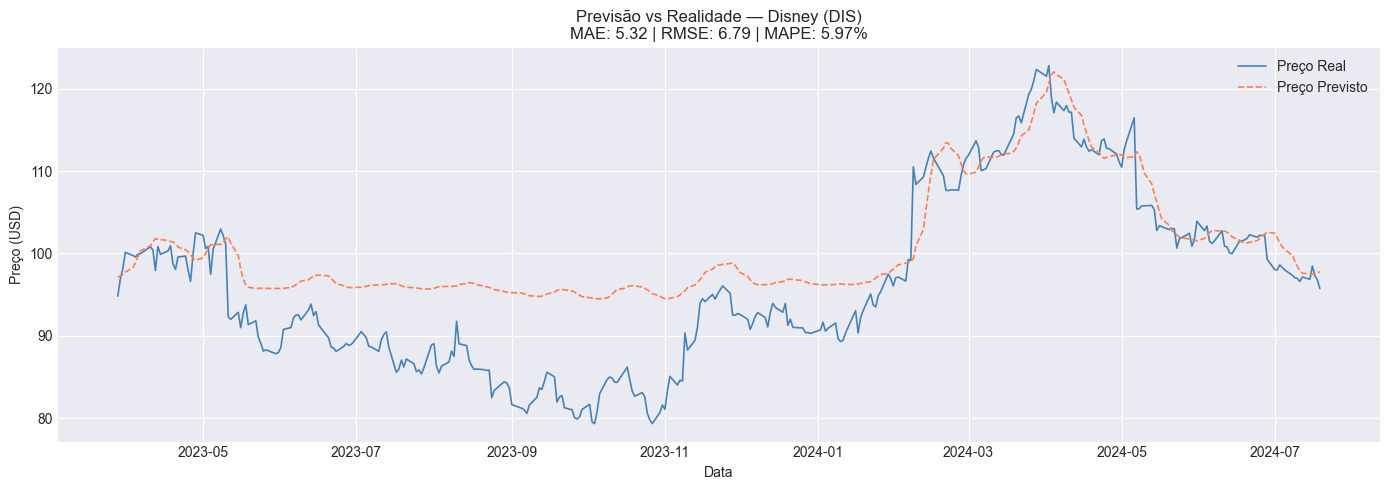

In [9]:
# Reconstrói o índice de datas do conjunto de teste
df_raw  = pd.read_csv(f'{DATA_DIR}/dis_raw.csv', index_col=0, parse_dates=True)
df_raw  = df_raw.dropna(subset=['Close'])

# As últimas len(y_real) datas correspondem ao conjunto de teste
test_index = df_raw.index[-len(y_real):]

plt.figure(figsize=(14, 5))
plt.plot(test_index, y_real, label='Preço Real',     color='steelblue', linewidth=1.2)
plt.plot(test_index, y_pred, label='Preço Previsto', color='coral',     linewidth=1.2, linestyle='--')
plt.title(
    f'Previsão vs Realidade — Disney (DIS)\n'
    f'MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%',
    fontsize=12
)
plt.ylabel('Preço (USD)')
plt.xlabel('Data')
plt.legend()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/predictions_vs_real.png', dpi=120)
plt.show()

## 10. Salvamento dos artefatos
Persiste o modelo final, as métricas e os arrays de previsão para uso na API e no monitoramento.

In [10]:
# Modelo final
model.save(f'{MODEL_DIR}/lstm_dis_final.keras')

# Métricas
with open(f'{MODEL_DIR}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Arrays de previsão
np.save(f'{MODEL_DIR}/y_pred.npy', y_pred)
np.save(f'{MODEL_DIR}/y_real.npy', y_real)

print('Artefatos salvos em model/:')
for fname in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'  {fname:<35} {size:>8.1f} KB')

Artefatos salvos em model/:
  .gitkeep                                 0.0 KB
  learning_curves.png                     42.1 KB
  lstm_dis_best.keras                   1419.7 KB
  lstm_dis_final.keras                  1419.7 KB
  metrics.json                             0.1 KB
  predictions_vs_real.png                 93.9 KB
  y_pred.npy                               1.4 KB
  y_real.npy                               2.7 KB


## Resumo do Treino

| Parâmetro | Valor |
|---|---|
| Arquitetura | LSTM(128) → Dropout(0.2) → LSTM(64) → Dropout(0.2) → Dense(32) → Dense(1) |
| Otimizador | Adam (lr=0.001) |
| Loss | MSE |
| Batch size | 32 |
| Épocas máx. | 100 (com EarlyStopping) |
| Validação | 20% do treino |
| Janela temporal | 60 dias |